# Bayesian Optimization

Imagine you need to find the best settings for a complex system – perhaps tuning the hyperparameters of a deep learning model, optimizing the design of an experiment, or finding the ideal parameters for a simulation. Often, evaluating the system with a given set of parameters (i.e., running the experiment or training the model) is expensive, time-consuming, or resource-intensive. How can you find the optimal settings without performing an exhaustive search?

This is where **Bayesian Optimization (BO)** comes in. It's a powerful, sequential strategy designed specifically for the **global optimization of black-box functions**. These are functions where:

1.  We don't know the underlying mathematical form (it's a "black box").
2.  Evaluating the function (getting an output `y` for an input `x`) is costly.
3.  We often cannot compute derivatives (gradients).
4.  The observations might be noisy (the output `y` can vary even for the same input `x`).

BO tackles this challenge by intelligently choosing the next point to evaluate, aiming to find the optimum (maximum or minimum) in as few evaluations as possible.

### Core Components

Bayesian Optimization cleverly balances exploring unknown parts of the search space and exploiting areas known to yield good results. It does this using two main components:

1.  **A Probabilistic Surrogate Model:** This model approximates the unknown objective function based on the points observed so far. It also provides uncertainty estimates about the function's behavior in unexplored regions. Gaussian Processes (GPs) are the most common choice for this surrogate model due to their flexibility and inherent uncertainty quantification.
2.  **An Acquisition Function:** This function uses the surrogate model's predictions (mean and uncertainty) to determine the 'utility' of evaluating any given point in the search space. It guides the search by suggesting the point that is most likely to lead to an improvement, considering both the predicted performance and the uncertainty. Examples include Expected Improvement (EI) and Upper Confidence Bound (UCB).

### The Iterative Process

The BO algorithm works iteratively:

1.  **Observe:** Evaluate the black-box function at one or more points chosen by the acquisition function.
2.  **Update:** Update the surrogate model (e.g., the Gaussian Process) using all the data collected so far (inputs and their observed outputs).
3.  **Select:** Optimize the acquisition function (which is cheap to evaluate) over the search space to find the most promising point(s) to evaluate next.
4.  **Repeat:** Continue this cycle until a stopping criterion is met (e.g., budget of function evaluations exhausted, desired performance level reached).


### Recommended reading:
1. [A Tutorial on Bayesian Optimization](https://arxiv.org/pdf/1807.02811)
1. [BayesOpt docs](https://bayesian-optimization.github.io/BayesianOptimization/2.0.3/)
1. [Exploring Bayesian Optimization](https://distill.pub/2020/bayesian-optimization/)
1. [Acquisition functions in Bayesian Optimization](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html)
1. [A Visual Exploration of Gaussian Processes](https://distill.pub/2019/visual-exploration-gaussian-processes/)
1. [Practical Bayesian Optimization of Machine Learning Algorithms](https://arxiv.org/abs/1206.2944)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

# Set random seed for reproducibility
np.random.seed(42)

### Define and visualize the target function
First, we'll create a synthetic objective function to optimize. This specific function has three peaks (at x=0, x≈2 and x≈6) and is a toy example.

$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}$$

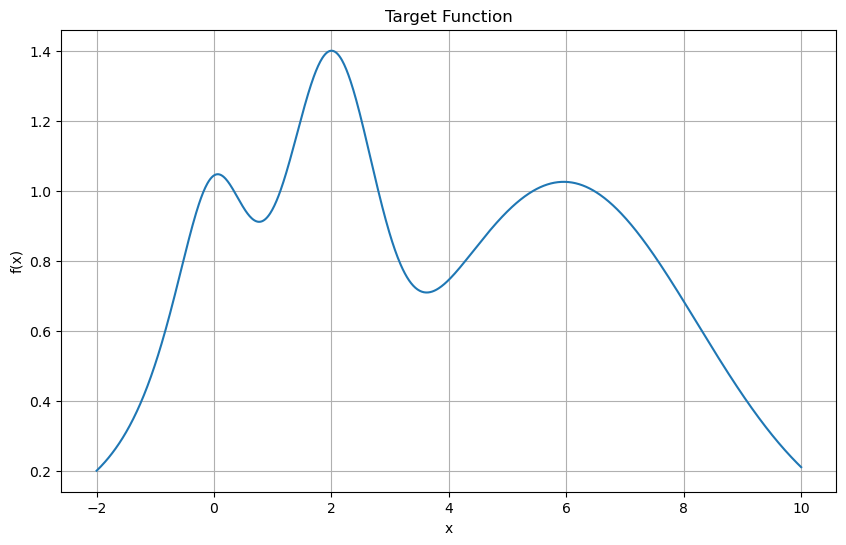

In [2]:
def target_function(x):
    """Our example target function to be optimized"""
    return np.exp(-((x - 2) ** 2)) + np.exp(-((x - 6) ** 2) / 10) + 1 / (x**2 + 1)


x = np.linspace(-2, 10, 1000)
y = target_function(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### Define visualization functions
These helper functions will visualize the Gaussian Process model
and acquisition function at each step of the optimization process.
They help us understand how the model evolves as more observations are made.

In [3]:
def posterior(optimizer, grid):
    """Get posterior mean and standard deviation from GP model"""
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y, save_path=None):
    """Plot the Gaussian Process model, observations, and acquisition function"""
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        f"Gaussian Process and Utility Function After {steps} Steps",
        fontsize=30,
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label="Target")
    axis.plot(
        x_obs.flatten(), y_obs, "D", markersize=8, label="Observations", color="r"
    )
    axis.plot(x, mu, "--", color="k", label="Prediction")

    axis.fill(
        np.concatenate([x, x[::-1]]),
        np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=0.6,
        fc="c",
        ec="None",
        label="95% confidence interval",
    )

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel("f(x)", fontdict={"size": 20})
    axis.set_xlabel("x", fontdict={"size": 20})

    utility_function = optimizer.acquisition_function
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x_flat = x.flatten()

    acq.plot(x_flat, utility, label="Utility Function", color="purple")
    acq.plot(
        x_flat[np.argmax(utility)],
        np.max(utility),
        "*",
        markersize=15,
        label="Next Best Guess",
        markerfacecolor="gold",
        markeredgecolor="k",
        markeredgewidth=1,
    )
    acq.set_xlim((-2, 10))
    acq.set_ylabel("Utility", fontdict={"size": 20})
    acq.set_xlabel("x", fontdict={"size": 20})

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

    return fig

We'll now see Bayesian Optimization in action, step by step.
At each step, observe:
1. How the GP model (dashed line) is updated
2. How the confidence interval (light blue area) changes
3. How the acquisition function (purple line) guides the next sample
4. Where the next sample point (gold star) is placed

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |

Step 0: Initial random points


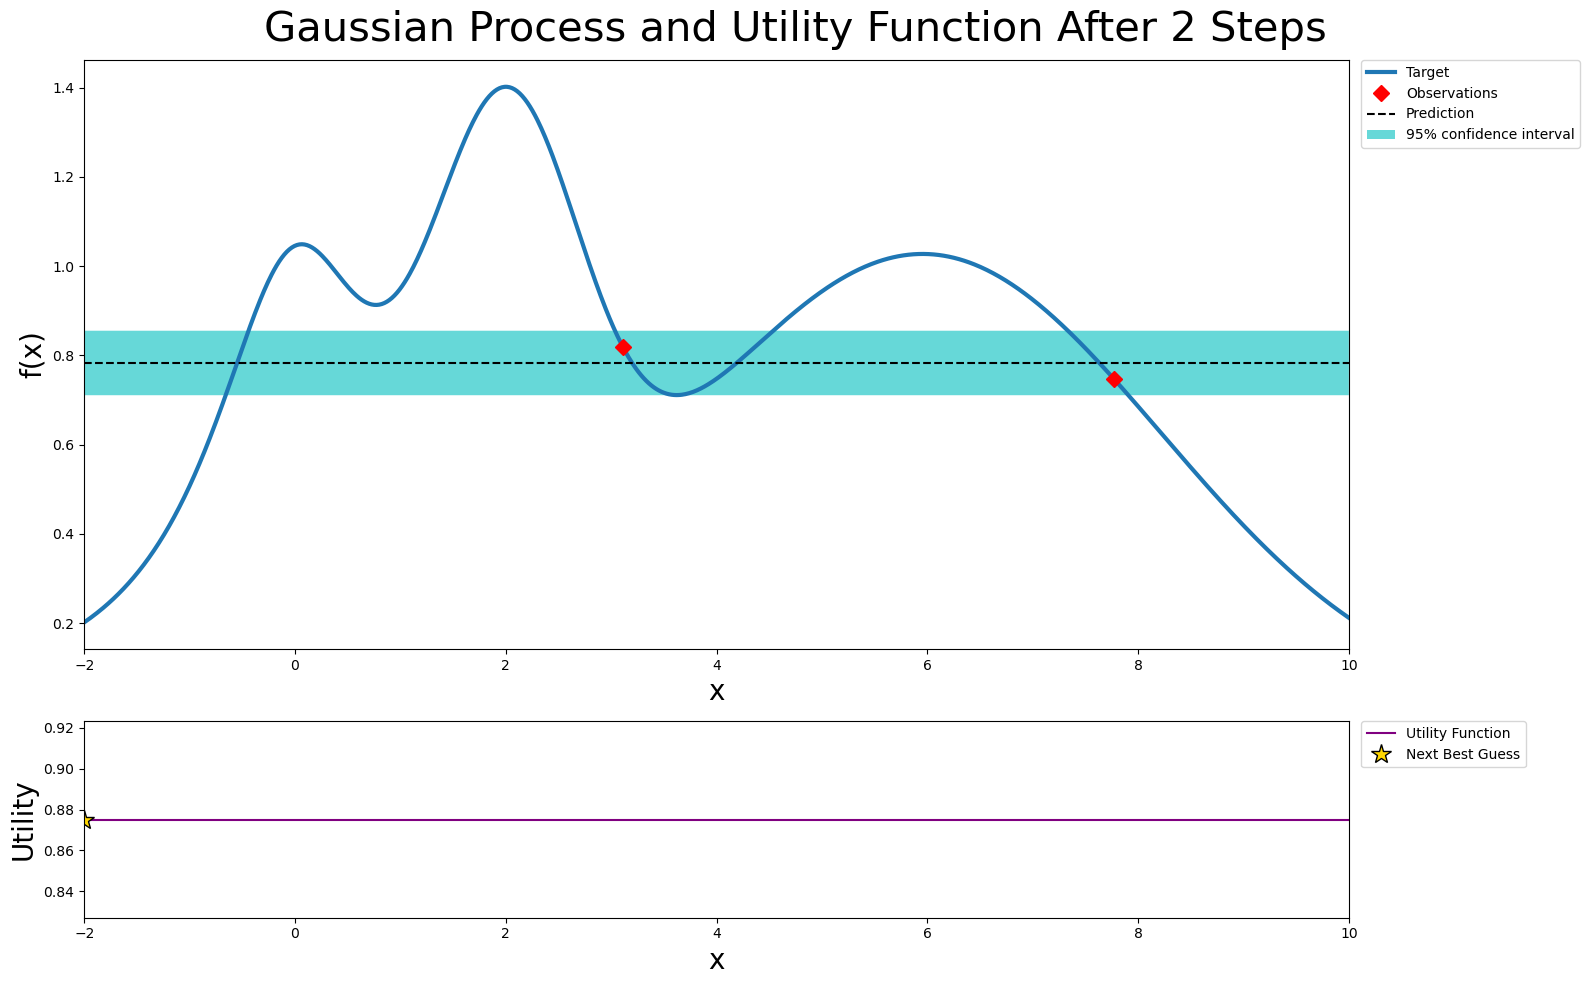

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.8190422 | 3.1102721 |

Step 1: Added a new observation


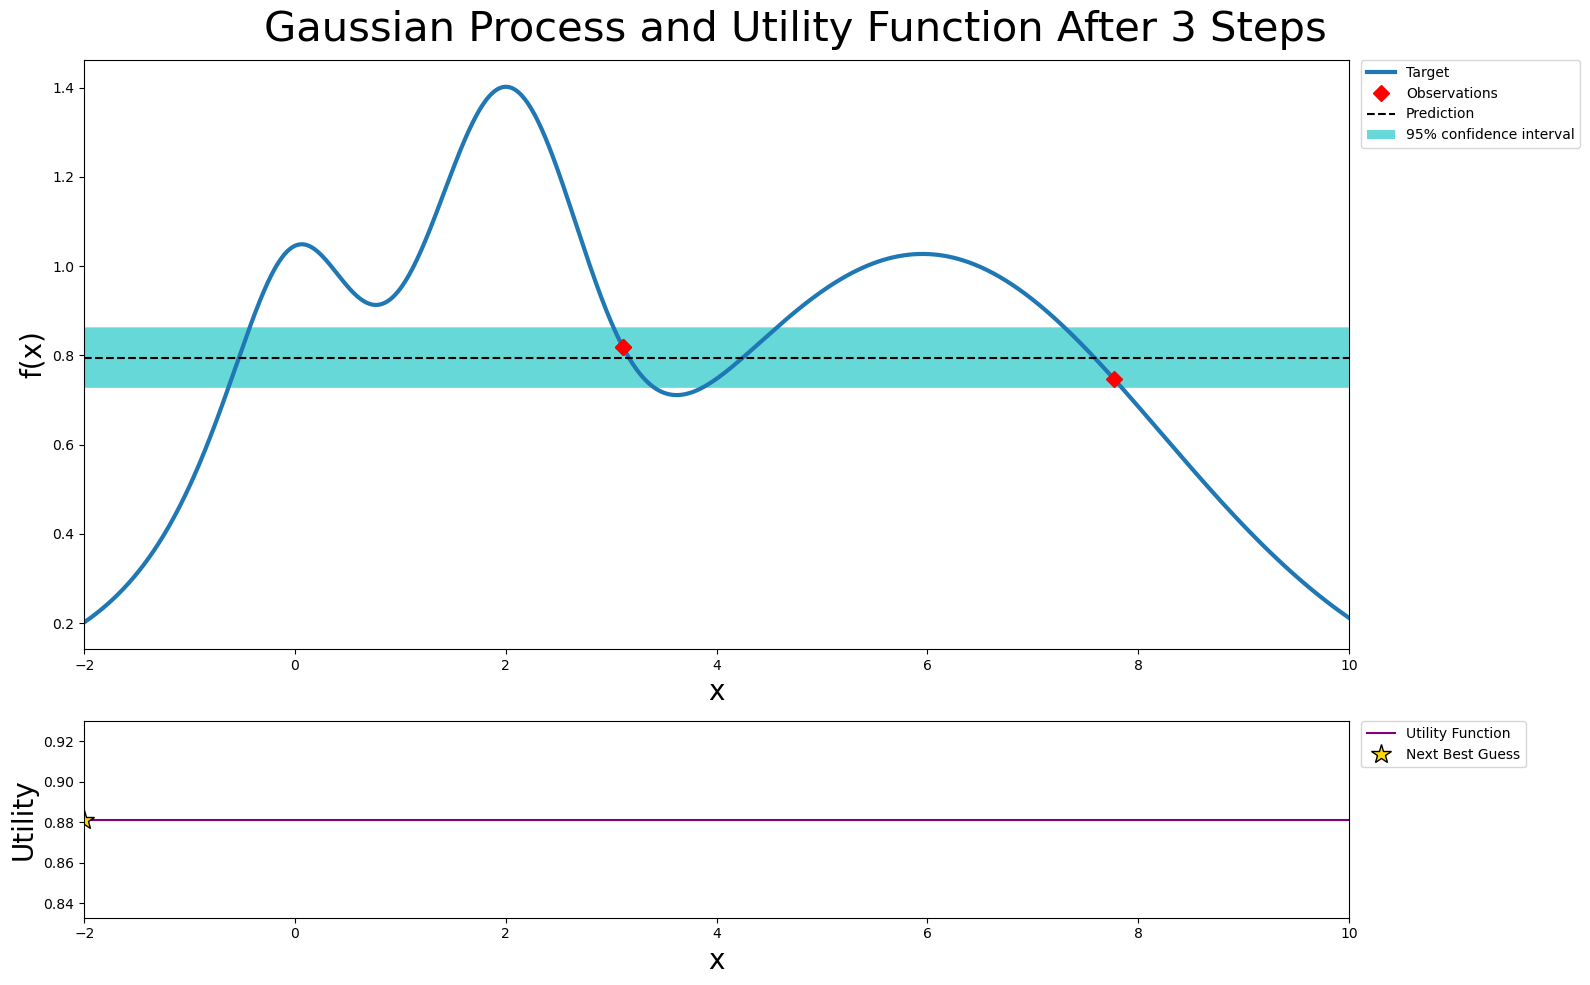

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 0.8943137 | 2.9649330 |

Step 2: Added a new observation


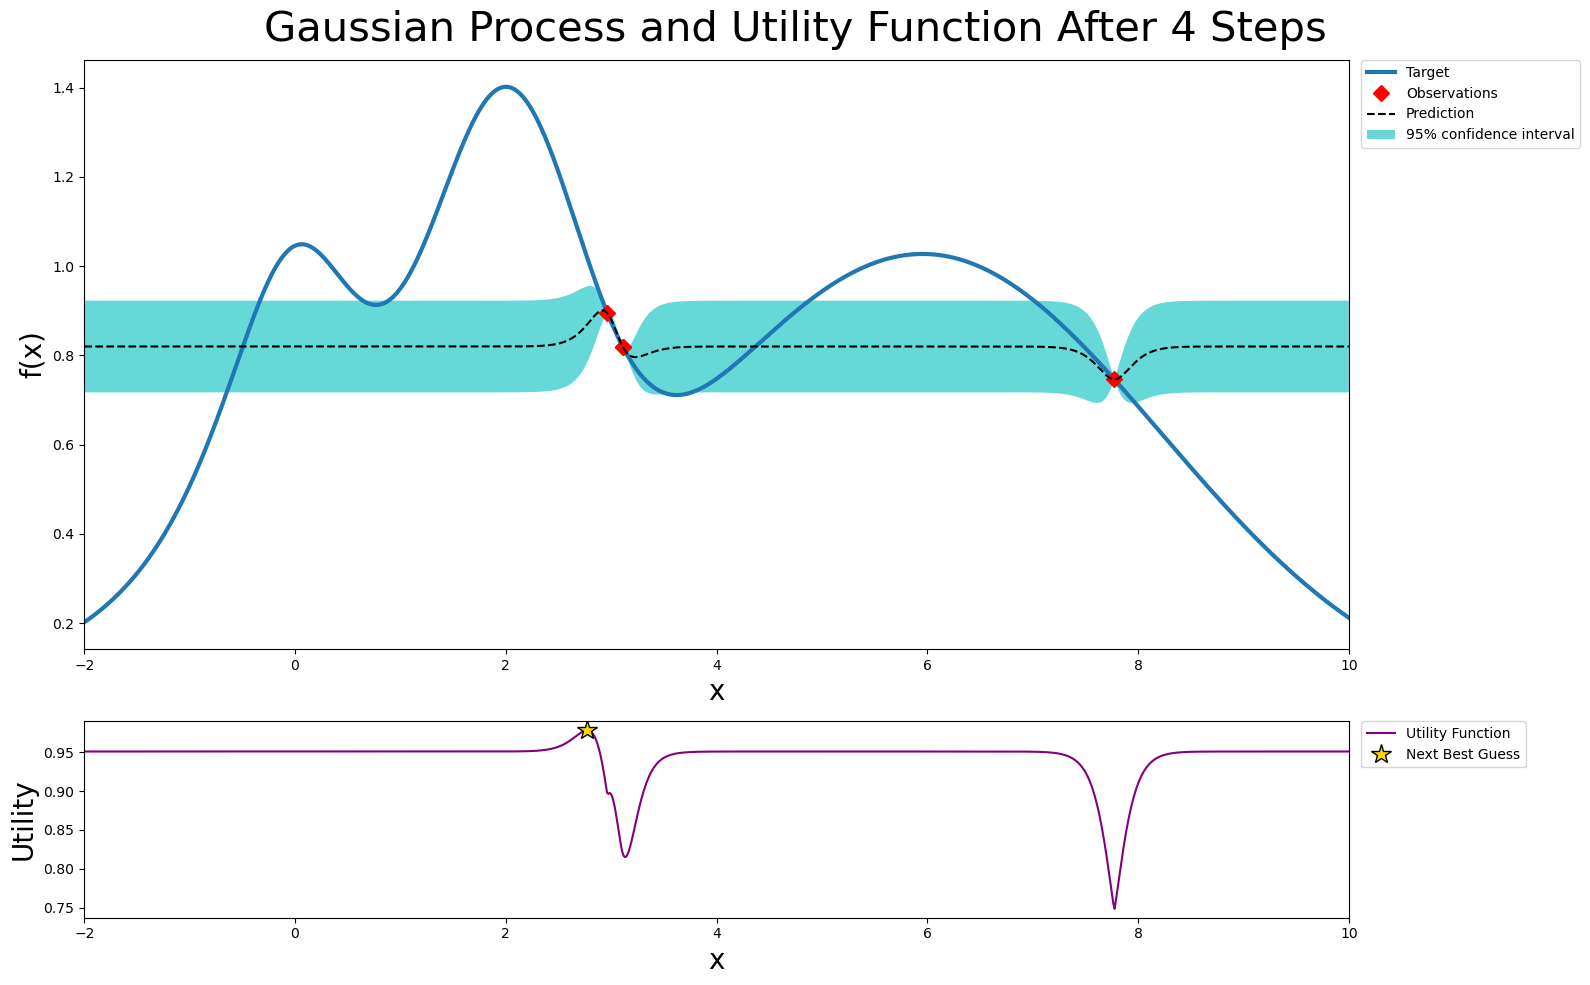

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 1.0188851 | 2.7720553 |

Step 3: Added a new observation


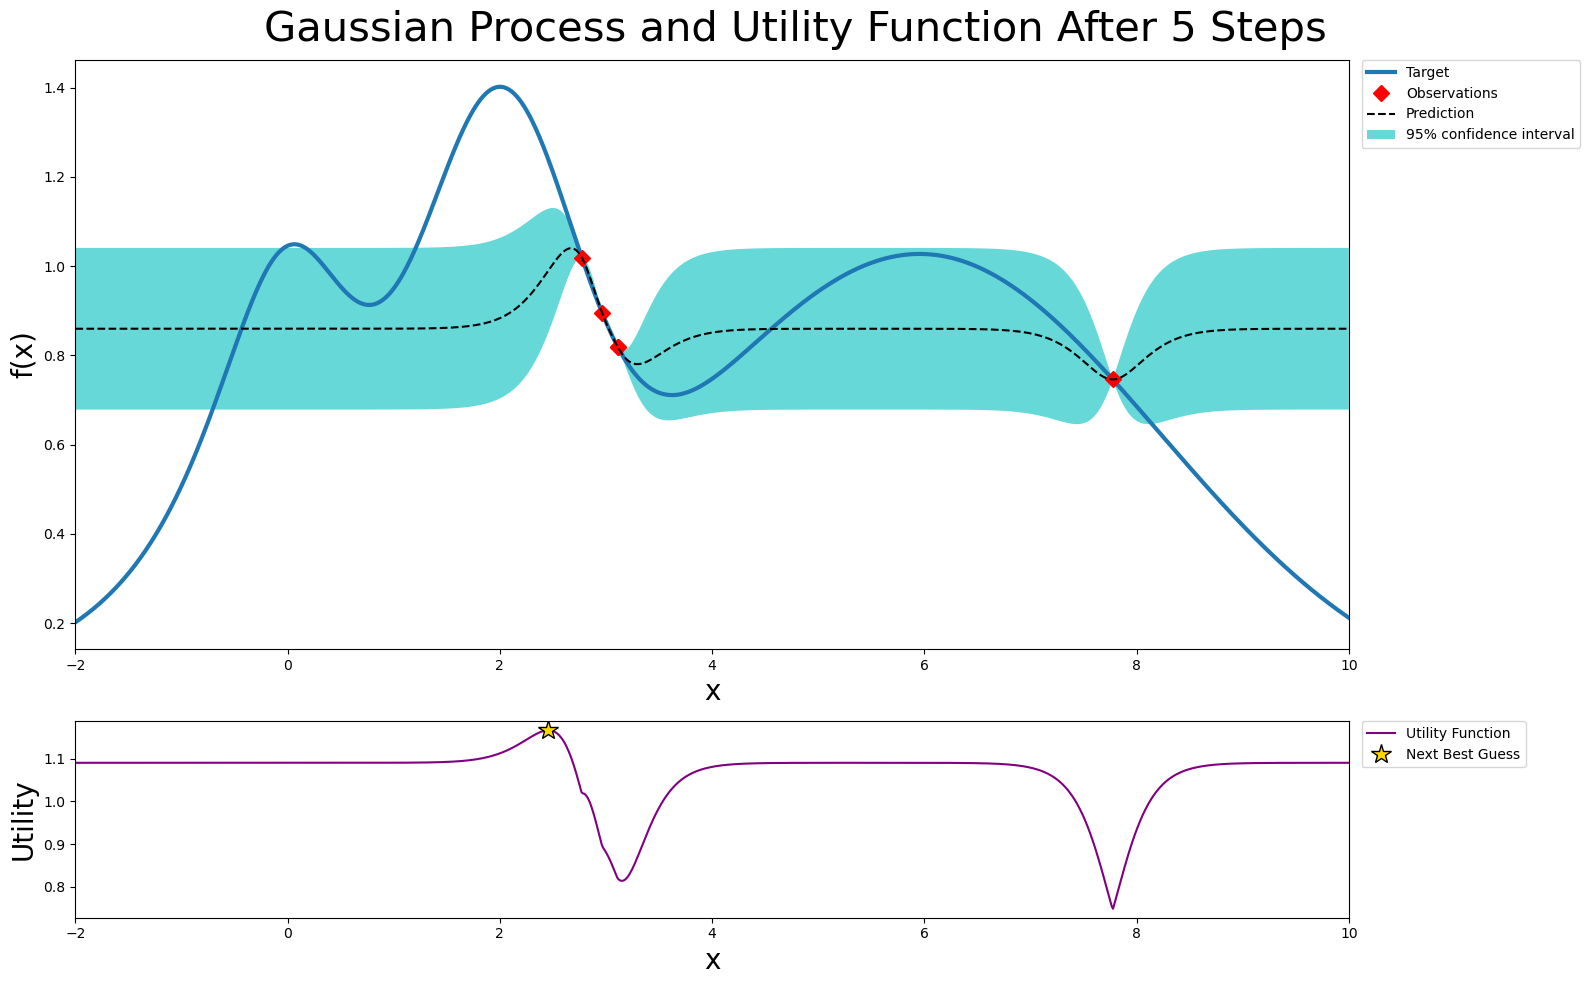

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 1.2389517 | 2.4564829 |

Step 4: Added a new observation


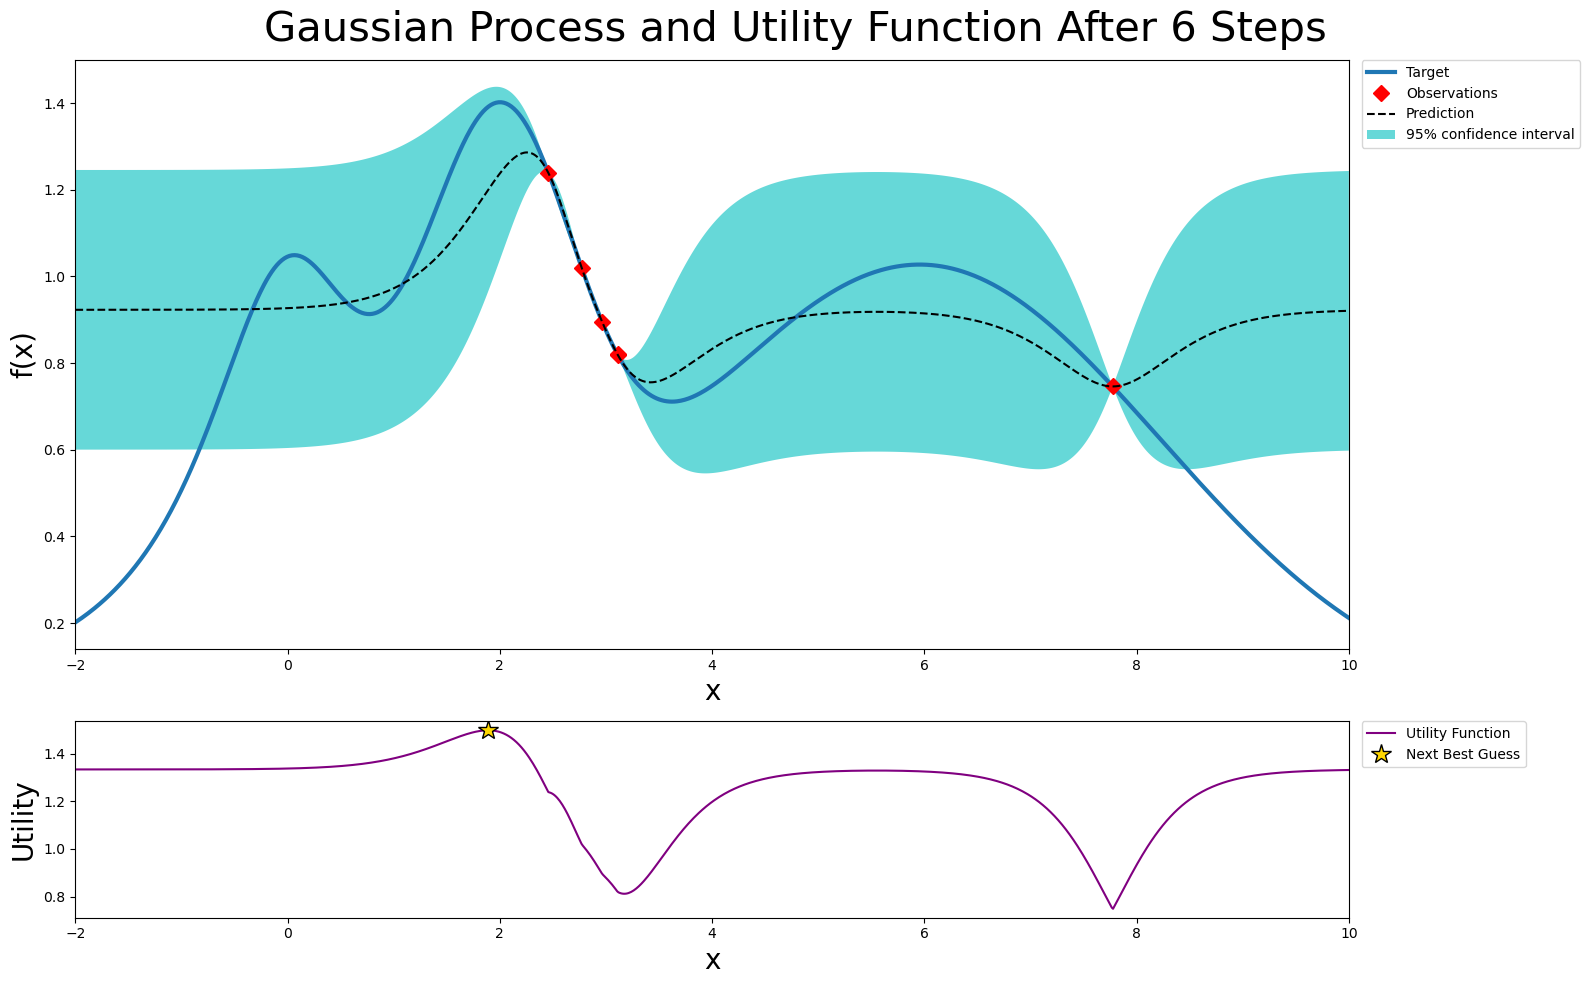

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 1.3911164 | 1.8887342 |

Step 5: Added a new observation


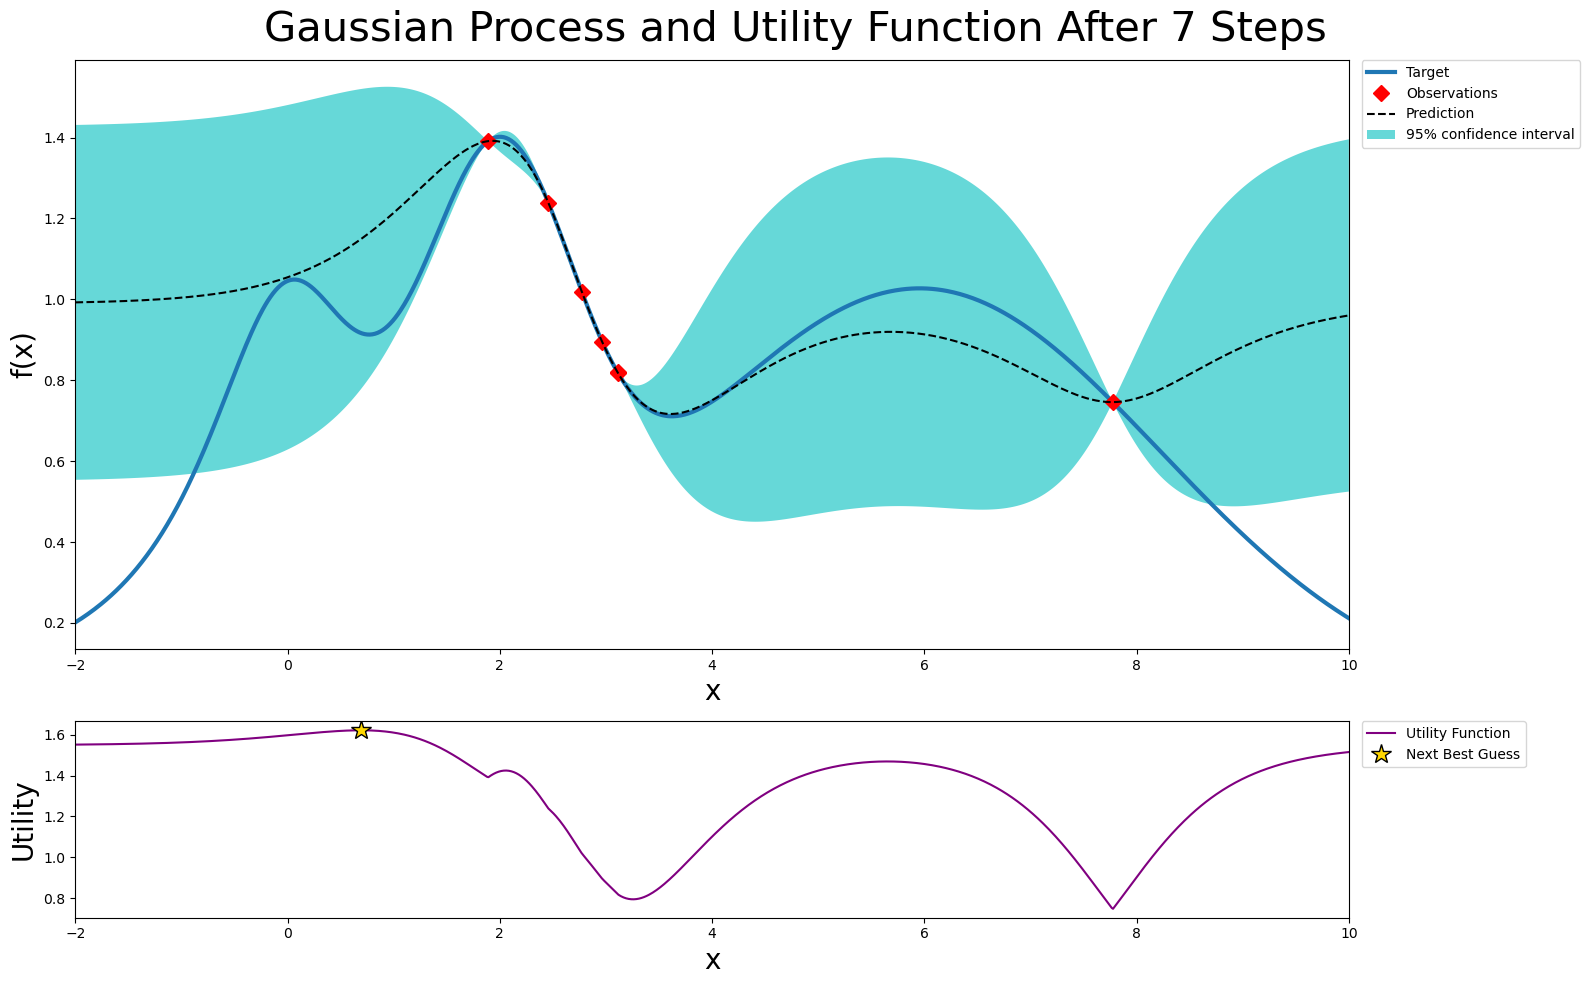


Final result:
Best target value found: 1.3911
Best input value found: x = 1.8887


In [4]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=acquisition_function,
    random_state=27,
)

# Prepare data for visualization
x = np.linspace(-2, 10, 1000).reshape(-1, 1)
y = target_function(x)

# Initialize with 2 random points
optimizer.maximize(init_points=2, n_iter=0)
print("\nStep 0: Initial random points")
plot_gp(optimizer, x, y)

for i in range(1, 6):
    optimizer.maximize(init_points=0, n_iter=1)
    print(f"\nStep {i}: Added a new observation")
    plot_gp(optimizer, x, y)

print("\nFinal result:")
print(f"Best target value found: {optimizer.max['target']:.4f}")
print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

Acquisition functions guide the sampling process by balancing:
- Exploitation: Sampling where the model predicts high values
- Exploration: Sampling where the model is uncertain

We'll compare three different acquisition functions:
1. Upper Confidence Bound (UCB): Balances exploration and exploitation
2. Probability of Improvement (PI): More exploitative
3. Greedy: Purely exploitative (custom implementation)

In [5]:
class GreedyAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return mean  # disregard std

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856627 | -0.211814 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351109 | 4.9507145 |

UCB Acquisition Function Results:


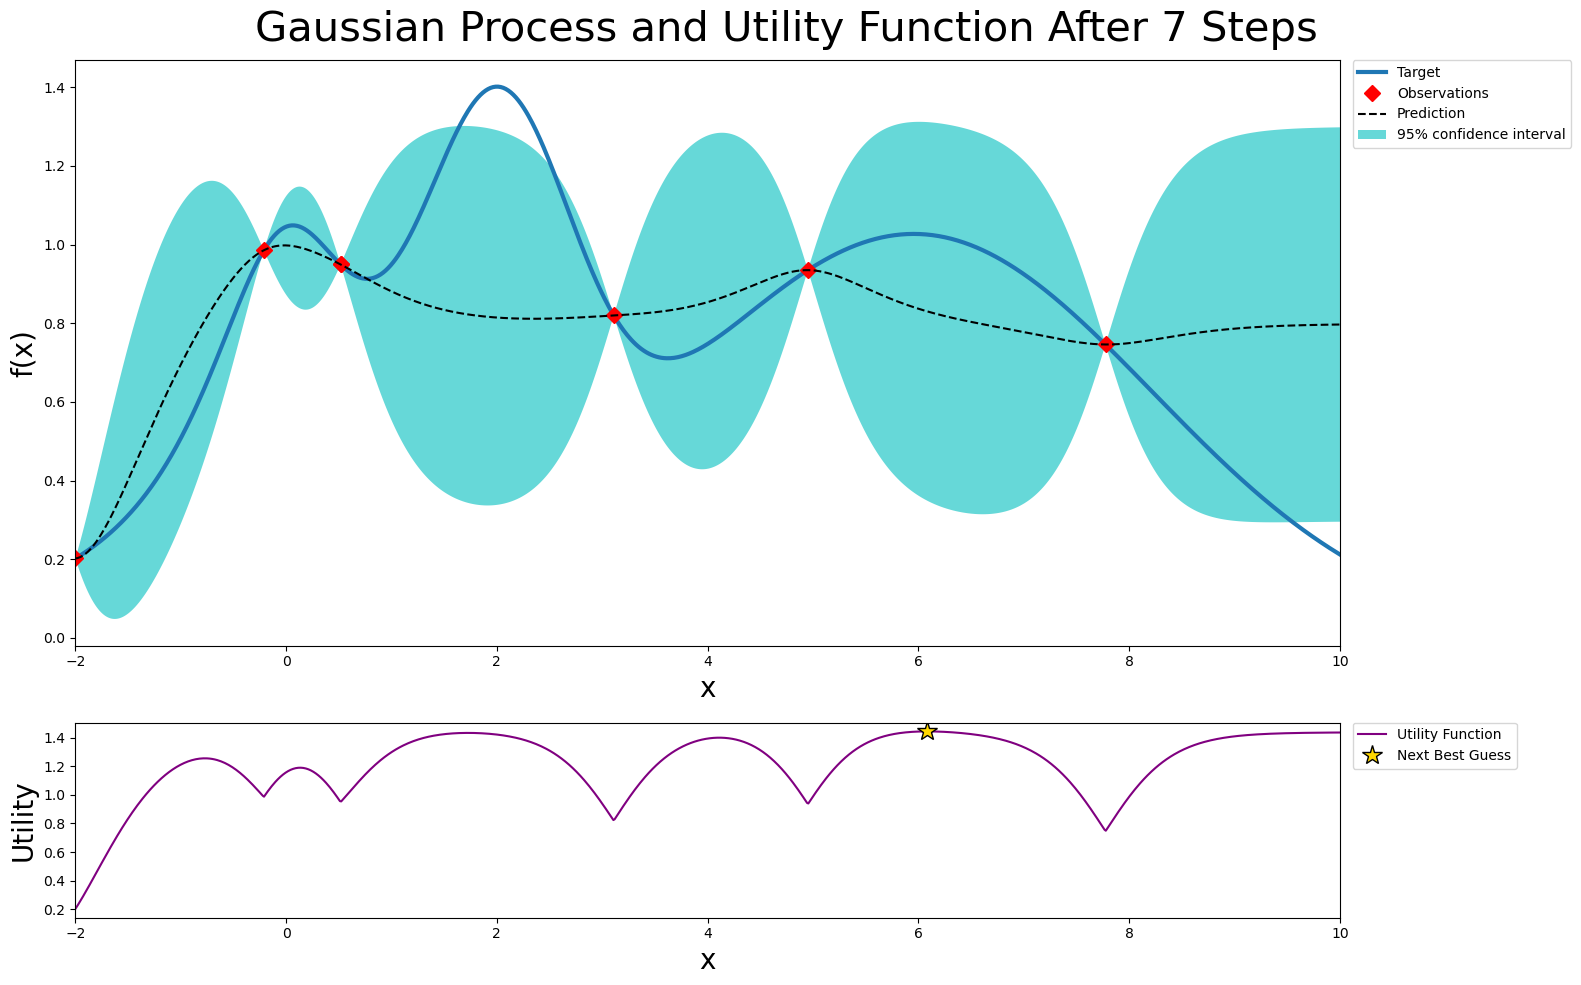

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

Probability of Improvement Acquisition Function Results:


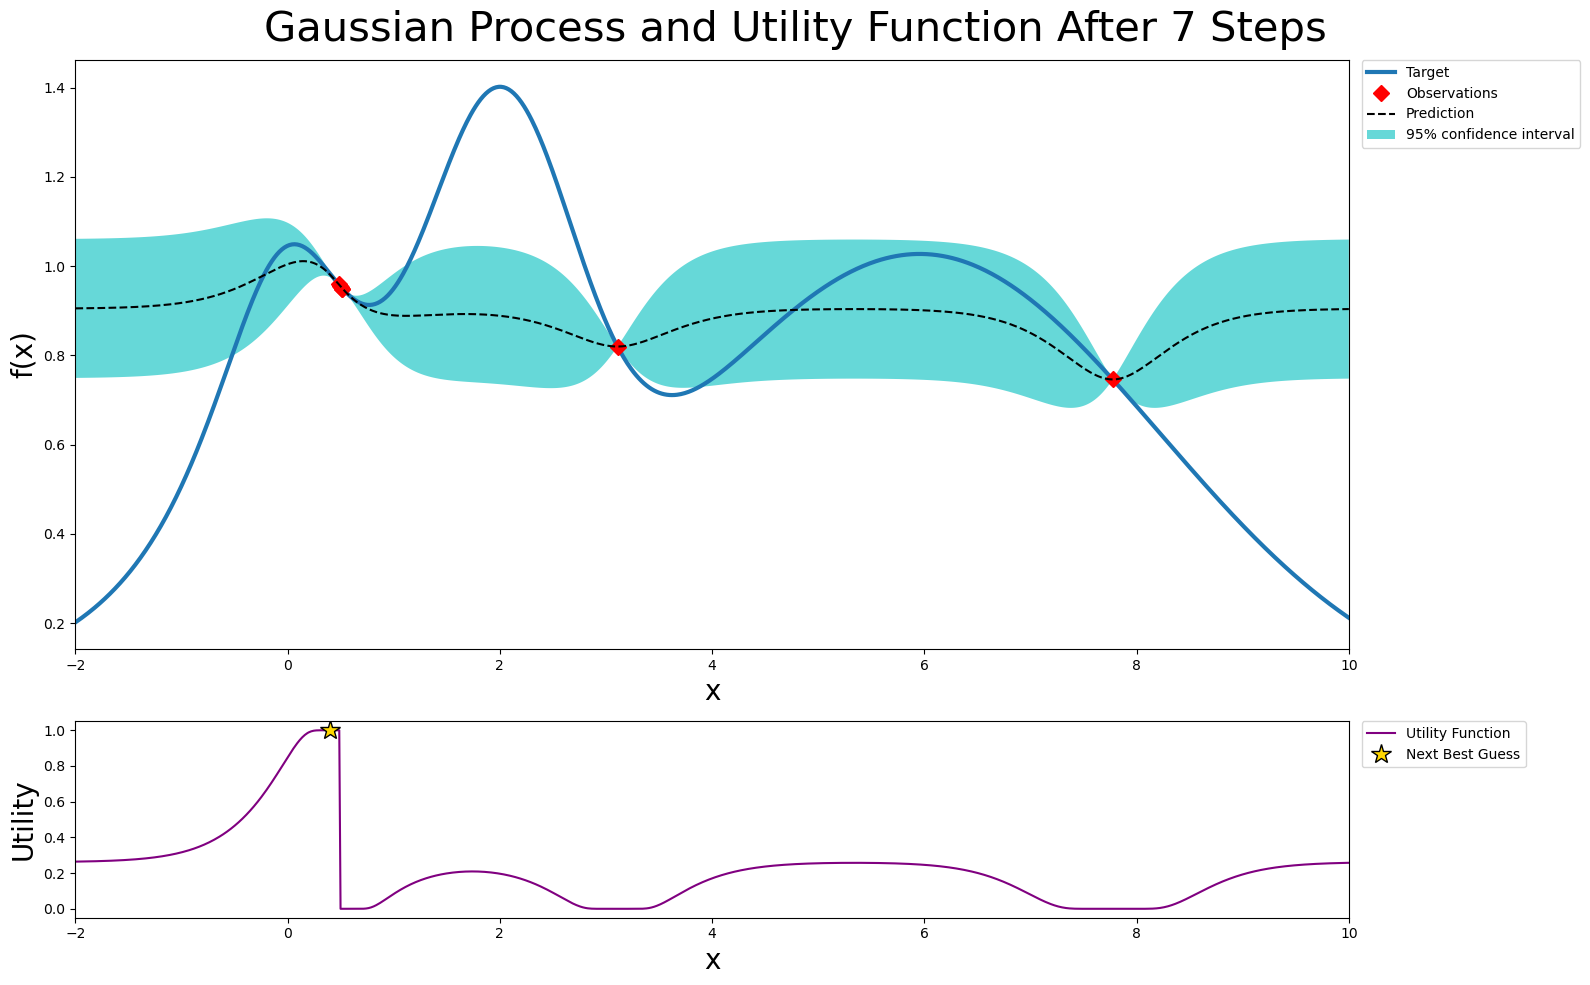

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495499 | 0.5165820 |
| 5         | 0.9495499 | 0.5165820 |
| 6         | 0.9495499 | 0.5165820 |
| 7         | 0.9495499 | 0.5165820 |

Greedy (Purely Exploitative) Acquisition Function Results:


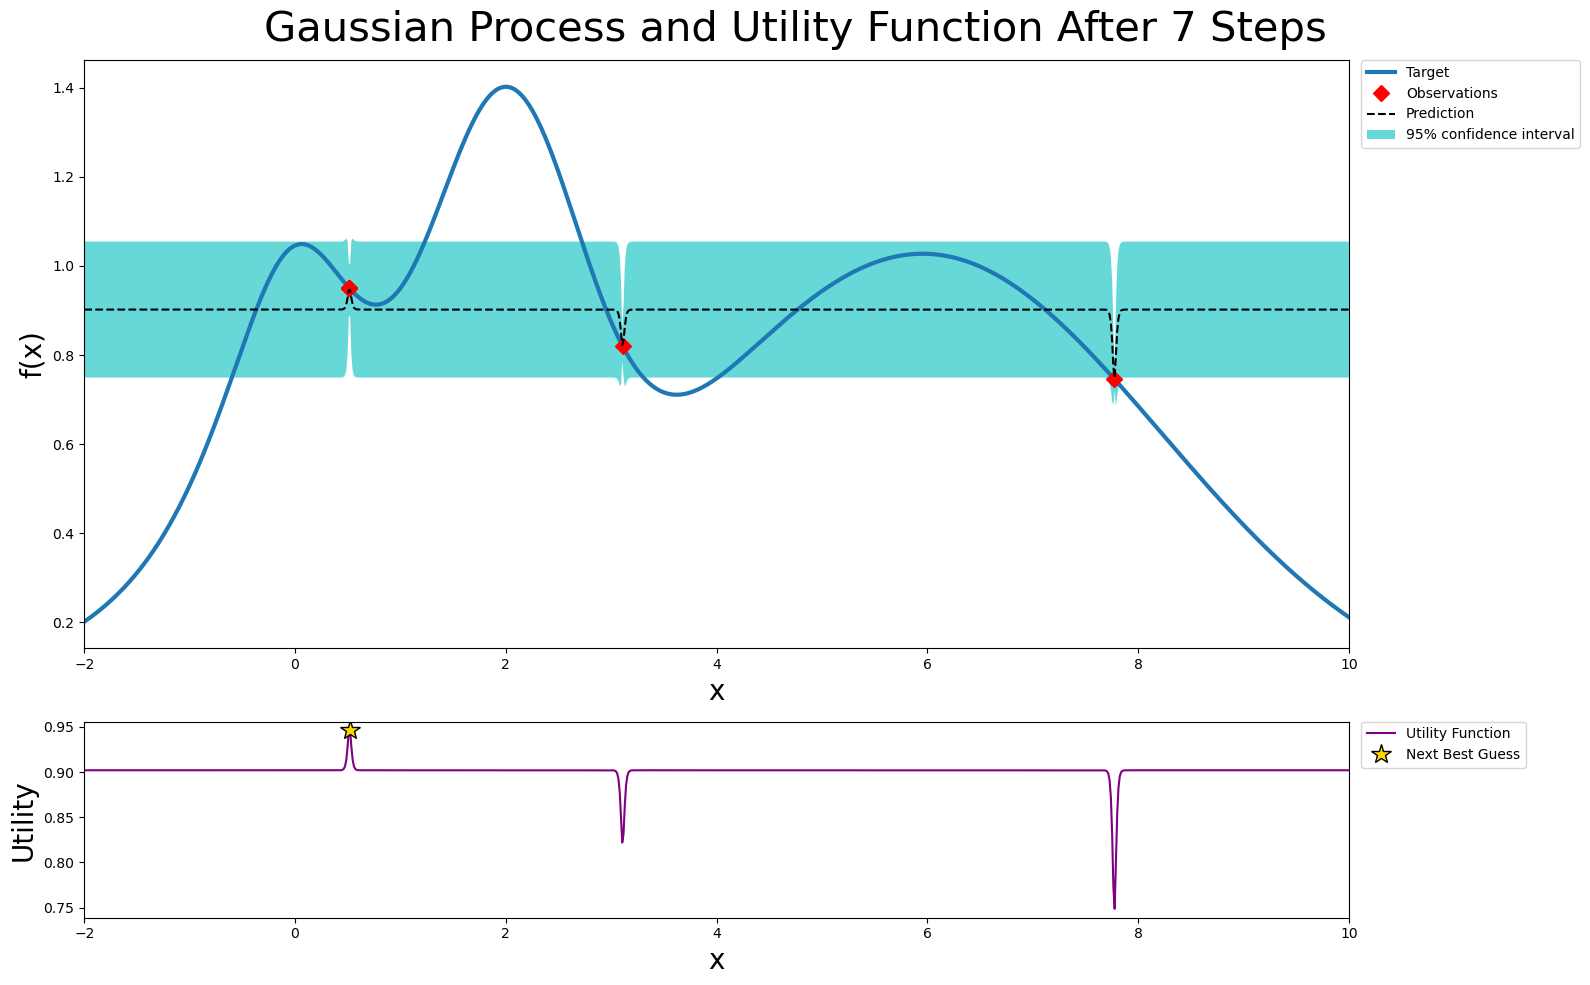


Summary of results:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Greedy best value: 0.9495 at x = 0.5166


In [6]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy (Purely Exploitative) Acquisition Function Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

Comment these results. Write your observations in a Markdown cell.

## KomentarzUCB

### Upper Confidence Bound
Najlepiej poradził sobie ze znalezieniem maksimum globalnego. Dzięki balansowi między eksploracją i eksploatacją przeszukał różne obszary funkcji i trafił w najlepszy wynik.

### PI (Probability of Improvement)
Szybko skupił się na obiecującym obszarze, ale mniej eksplorował przestrzeń i znalazł dobre, ale niekoniecznie globalnie najlepsze rozwiązanie.

### Greedy (czysto eksploatacyjny)
Skupił się praktycznie tylko na jednym lokalnym maksimum i przestał eksplorować. W efekcie utknął w lokalnym optimum i nie znalazł lepszych obszarów.

Exercise 1: UCB
---------------

The parameter kappa in the UCB acquisition function controls the trade-off between:
- Exploration (high kappa): More emphasis on the uncertainty
- Exploitation (low kappa): More emphasis on the predicted mean

Compare results for UCB using 3 different values:
1. kappa = 0.1 (Mostly exploitation)
2. kappa = 2.5 (Balanced)
3. kappa = 5.0 (Mostly exploration)

Review this [blog post](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html) and explain the underlying concept of UCB in a Markdown cell.

## Komentarz
Funkcja UCB wybiera kolejny punkt jako sumę przewidywanej wartości i niepewności, dzięki czemu balansuje między eksploracją a eksploatacją. Parametr kappa kontroluje ten balans – dla małej wartości algorytm skupia się głównie na znanych dobrych obszarach, co może prowadzić do utknięcia w lokalnym maksimum. Dla średniej uzyskujemy rozsądny kompromis, który zwykle daje najlepsze wyniki. Natomiast duże kappa powoduje intensywną eksplorację, przez co algorytm częściej sprawdza nieznane obszary, ale może wolniej znaleźć optimum.

Exercise 2: Chaotic Acquisition Function
-----------------------------------------
**Goal**: Implement a chaotic acquisition function that exclusively prioritizes the standard deviation of predictions, disregarding the predicted mean. Compare its performance against standard acquisition functions such as UCB and PI (Probability of Improvement).

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.4795761 | -1.056368 |
| 5         | 0.5994353 | 8.3148223 |
| 6         | 0.9551109 | 1.0156908 |
| 7         | 0.9990032 | 5.4116415 |

Chaotic Acquisition Function Results:


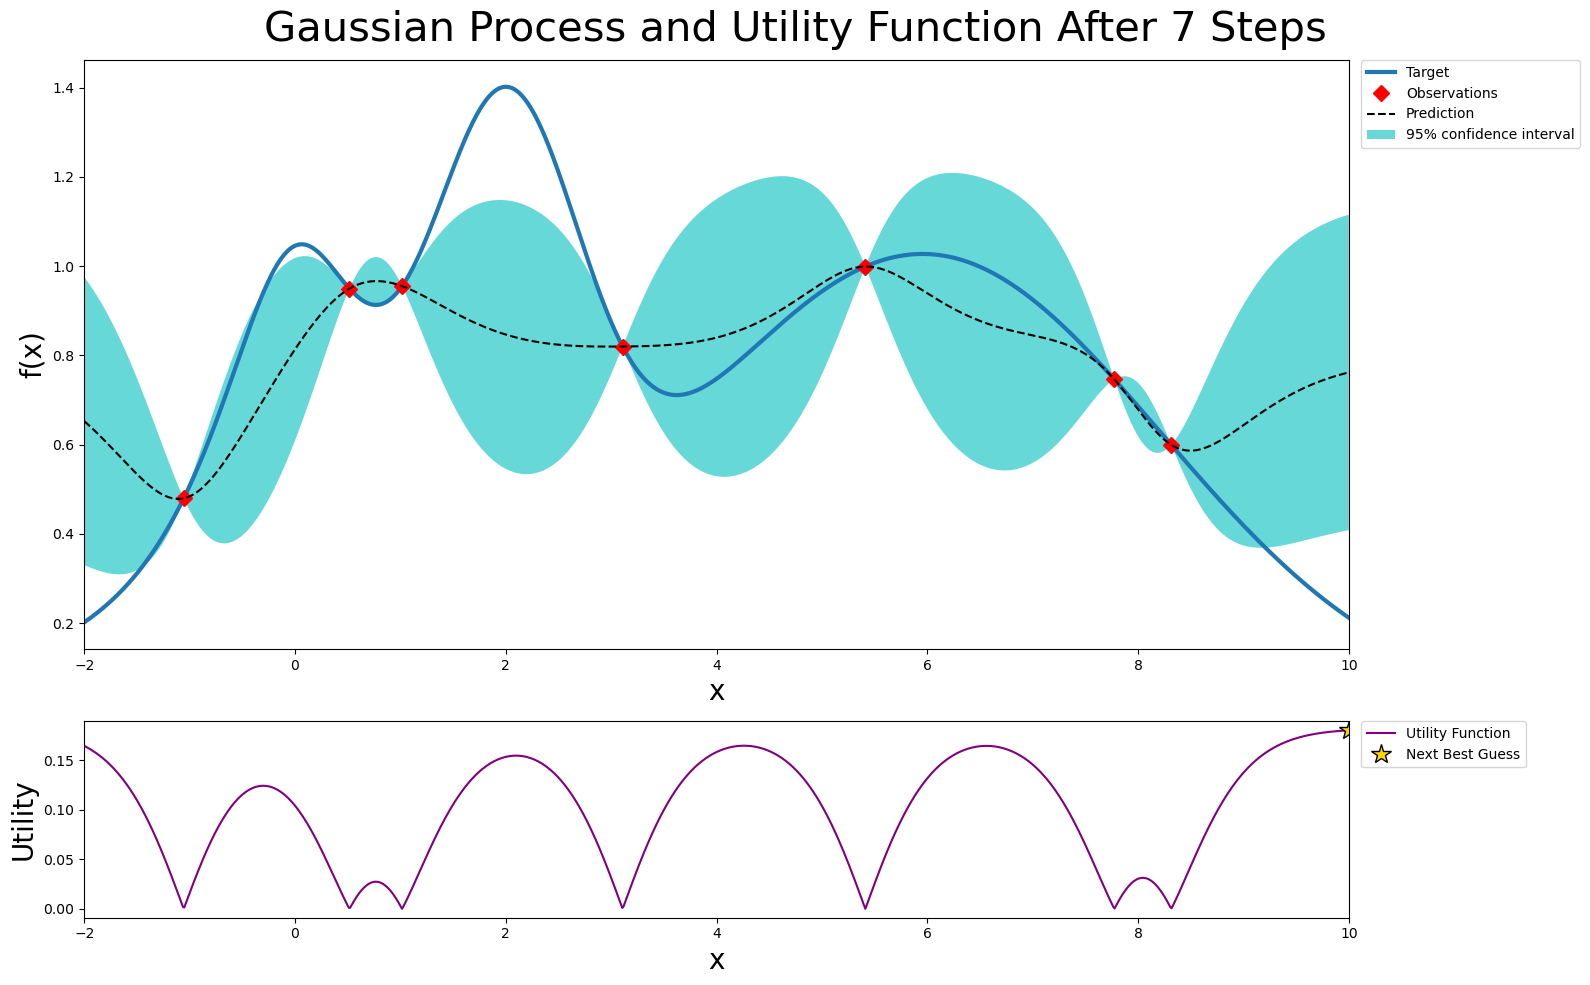

Chaotic best value: 0.9990 at x = 5.4116


In [9]:
class ChaoticAcquisition(acquisition.AcquisitionFunction):
    """Acquisition function skupiajaca sie na eksploracji (ignoruje srednia)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return std

chaotic = ChaoticAcquisition()
optimizer_chaotic = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=chaotic,
    random_state=27,
)

optimizer_chaotic.maximize(init_points=2, n_iter=5)

print("\nChaotic Acquisition Function Results:")
plot_gp(optimizer_chaotic, x, y)

print(f"Chaotic best value: {optimizer_chaotic.max['target']:.4f} at x = {optimizer_chaotic.max['params']['x']:.4f}")

In [11]:
# Do porównania
print("\nComparison:")
print(f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}")
print(f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}")
print(f"Chaotic best value: {optimizer_chaotic.max['target']:.4f} at x = {optimizer_chaotic.max['params']['x']:.4f}")


Comparison:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Chaotic best value: 0.9990 at x = 5.4116


## Komentarz
Spośród porównywanych metod **najlepszy wynik uzyskała chaotic acquisition function**, co oznacza, że w tym przypadku czysta eksploracja pozwoliła znaleźć punkt bardzo bliski globalnemu maksimum. 
**UCB** osiągnęło nieco słabszy wynik, ale nadal działało dobrze dzięki połączeniu eksploracji i eksploatacji. 
**PI** wypadło najsłabiej, ponieważ szybciej skupiło się na lokalnie dobrych obszarach i mniej badało resztę przestrzeni.

Widać więc, że dla tej konkretnej funkcji **chaotic okazało się najskuteczniejsze**, ale nie oznacza to, że zawsze będzie najlepsze. Jego działanie jest mniej stabilne, bo ignoruje przewidywaną wartość funkcji i kieruje się tylko niepewnością.

Exercise 3: Expected Improvement
--------------------------------

**Goal:** Implement the Expected Improvement (EI) acquisition function by extending the `AcquisitionFunction` base class provided by the `BayesOpt` library.

Expected Improvement (EI) is a popular choice for the acquisition function. Let's understand its derivation:

1.  **Current Best:** After $n$ evaluations, the best function value observed *so far* is $f^* = \max_{m=1..n} f(x_m)$.

2.  **Potential Improvement:** If we evaluate a new point $x$, the *actual* improvement over the current best $f^*$ is $\max(f(x) - f^*, 0)$, sometimes written as $[f(x) - f^*]^+$.

3.  **The Challenge:** We want to choose $x$ to maximize this improvement, but $f(x)$ is unknown *before* evaluation.

4.  **The Solution: Expected Improvement:** Our probabilistic model gives a posterior distribution for $f(x)$ at any point $x$. Given the data, this is typically a Gaussian distribution: $f(x) \sim \mathcal{N}(\mu_n(x), \sigma_n^2(x))$. EI maximizes the *expected* value of the improvement, where the expectation is taken over this posterior distribution:

    $EI_n(x) = E_n[ \max(f(x) - f^*, 0) ]$

    This value represents, on average, how much we expect to improve upon $f^*$ by evaluating at $x$. The next point chosen is the one that maximizes $EI_n(x)$.

### Mathematical Formulation

The expected improvement integral can be computed analytically. The standard closed-form expression is:

$$
EI(x) =
\begin{cases}
(\mu(x) - f^*) \Phi(Z) + \sigma(x) \varphi(Z) & \text{if } \sigma(x) > 0 \\
0 & \text{if } \sigma(x) = 0
\end{cases}
$$

Where:

* $\mu(x)$: The posterior mean of $f(x)$ at point $x$.
* $\sigma(x)$: The posterior standard deviation of $f(x)$ at point $x$.
* $f^*$: The best function value observed so far (a single scalar value).
* $Z = \frac{\mu(x) - f^*}{\sigma(x)}$
* $\Phi(Z)$: The Cumulative Distribution Function (CDF) of the standard normal distribution $\mathcal{N}(0, 1)$.
* $\varphi(Z)$: The Probability Density Function (PDF) of the standard normal distribution $\mathcal{N}(0, 1)$.

### Implementation Task

Create a class `ExpectedImprovement` inheriting from `acquisition.AcquisitionFunction` and implement the core calculation in the `base_acq` method. The signature of `base_acq` method looks like this:
```python
def base_acq(self, mean: NDArray[Float], std: NDArray[Float]) -> NDArray[Float]:
```

Compare its performance against other acquisition functions.

Hint: Analyse the source code of [ProbabilityOfImprovement](https://github.com/bayesian-optimization/BayesianOptimization/blob/d5126dc2462fddf50047519d6ef6125f271e0650/bayes_opt/acquisition.py#L583) class to better understand how to use/update $f^*$ (`self.y_max`).

In [15]:
from scipy.stats import norm
class MyExpectedImprovement(acquisition.AcquisitionFunction):
    """Custom Expected Improvement acquisition function"""

    def __init__(self, xi=1e-4, random_state=None):
        super().__init__(random_state)
        self.xi = xi
        self.y_max = None

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        if self.y_max is None:
            raise ValueError("y_max is not set.")

        # zabezpieczenie przed dzieleniem przez 0
        std = np.maximum(std, 1e-12)

        a = mean - self.y_max - self.xi
        z = a / std
        ei = a * norm.cdf(z) + std * norm.pdf(z)

        # jeśli sigma ~ 0, EI = 0
        ei[std <= 1e-12] = 0.0
        return ei

    def suggest(
        self,
        gp,
        target_space,
        n_random=10_000,
        n_smart=10,
        fit_gp=True,
        random_state=None,
    ):
        y_max = target_space._target_max()
        self.y_max = y_max

        return super().suggest(
            gp=gp,
            target_space=target_space,
            n_random=n_random,
            n_smart=n_smart,
            fit_gp=fit_gp,
            random_state=random_state,
        )

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495496 | 0.5165830 |
| 5         | 1.0170648 | 0.2802821 |
| 6         | 1.0486129 | 0.0424228 |
| 7         | 0.7648222 | -0.576904 |

Expected Improvement Results:


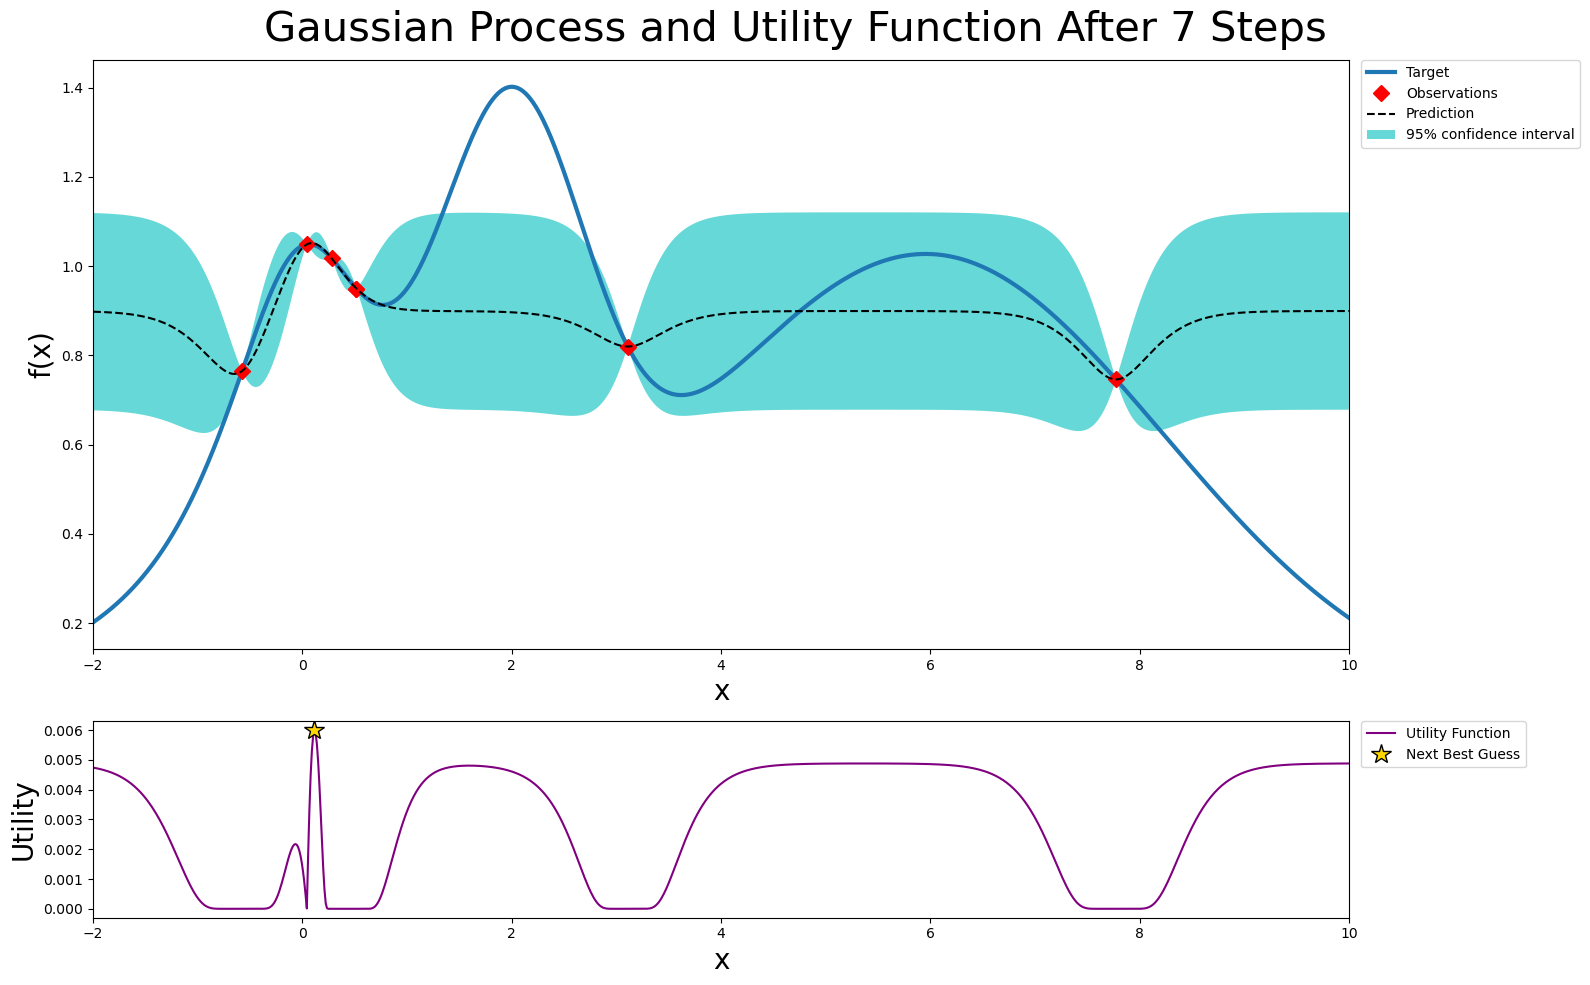


Comparison:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Chaotic best value: 0.9990 at x = 5.4116
EI best value: 1.0486 at x = 0.0424


In [16]:
# EI
ei = MyExpectedImprovement(xi=1e-4)
optimizer_ei = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ei,
    random_state=27,
)

optimizer_ei.maximize(init_points=2, n_iter=5)

print("\nExpected Improvement Results:")
plot_gp(optimizer_ei, x, y)

# porównanie
print("\nComparison:")
print(f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}")
print(f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}")
print(f"Chaotic best value: {optimizer_chaotic.max['target']:.4f} at x = {optimizer_chaotic.max['params']['x']:.4f}")
print(f"EI best value: {optimizer_ei.max['target']:.4f} at x = {optimizer_ei.max['params']['x']:.4f}")

## Komentarz
Expected Improvement osiągnęło **najlepszy wynik ze wszystkich metod**. Wynika to z faktu, że EI uwzględnia zarówno **prawdopodobieństwo poprawy**, jak i **wielkość tej poprawy**, dzięki czemu skuteczniej kieruje się w stronę globalnego maksimum.

EI jest jedną z najbardziej efektywnych funkcji akwizycji, ponieważ bierze pod uwagę nie tylko czy można poprawić wynik, ale też o ile.

Exercise 4: Theoretical Questions
--------------------------------
1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions?
2. Compare and contrast the different acquisition functions discussed in this tutorial.
3. What are the limitations of Bayesian Optimization?

### Odpowiedzi

1. Dlaczego BO jest przydatne dla drogich funkcji?

Bo minimalizuje liczbę wywołań funkcji. Najpierw buduje model przybliżający i wybiera tylko najbardziej obiecujące miejsca do sprawdzenia, zamiast strzelać "na ślepo".

2. Porównanie funkcji akwizycji

- UCB: balans eksploracji i eksploatacji, stabilna i uniwersalna
– PI:  skupia się na poprawie wyniku, może utknąć lokalnie
- EI: uwzględnia zarówno szansę poprawy, jak i jej wielkość
- Greedy: tylko eksploatacja, łatwo wpada w lokalne maksimum
- Chaotic: tylko eksploracja, dobrze przeszukuje przestrzeń, ale nie jest efektywna w znajdowaniu maksimum

3. Ograniczenia BO
- słabo skaluje się do dużej liczby wymiarów
- wymaga wyboru odpowiedniego modelu (np. GP)
- może być wolne przy dużej liczbie obserwacji
- działa gorzej przy bardzo szumnych danych
- trudniejsze do zastosowania w problemach z wieloma zmiennymi lub ograniczeniami